# Project 3b: Pose-Graph SLAM

In this assignment you will build a pose-graph SLAM pipeline using your ICP from P3a.
You will convert encoder readings to odometry, construct factor graphs with odometry
and ICP factors, and optimize them with GTSAM to correct drift and build maps.

**What you will implement**:

1. `encoders_to_odometry` wheel encoder ticks to SE2 poses (3 pts)
2. `build_single_robot_graph` single-robot factor graph with odom + ICP (6 pts)
3. `build_multi_robot_graph` multi-robot graph with range factors (6 pts)

**What you will submit:** `slam.py` to Gradescope Project 3b - SLAM (15 pts total).

This is the same workflow as 3a: read the prompts, implement functions in [`p3_lib/slam.py`](../p3_lib/slam.py), run cells top-to-bottom. Parameters and seeds match the autograder, so keep them unchanged. ICP from P3a is called directly by the SLAM pipeline.

## Setup & Imports

In [1]:
%matplotlib inline
import numpy as np
import sys
import gtsam
import matplotlib.pyplot as plt

sys.path.append('..')

from p3_lib.navigation import (
    WaypointController, RandomWalkController,
    RECTANGLE_WAYPOINTS, THREE_ROOM_WAYPOINTS,
)
from p3_lib.lidar import (
    simulate_lidar,
    ALL_SEGMENTS, ALL_SEGMENTS_ROOM
)
from p3_lib.icp import world_to_local, apply_pose2, icp
from p3_lib.slam import (
    encoders_to_odometry,
    simulate_uwb,
    build_single_robot_graph,
    build_multi_robot_graph,
)

import rps.robotarium as robotarium
from rps.utilities.barrier_certificates import (
    create_unicycle_barrier_certificate_with_boundary,
)

from scripts.robotarium_experiment import (
    ALL_SEGMENTS as HIDDEN_SEGMENTS,
    INIT_POSES
)

## The Initial Guess Experiment

As discussed in P3a, ICP converges to a local minimum. In a featureless environment (e.g., a flat wall), there can be many local minima -- the algorithm can "slide" along the wall and find low error at the wrong position.

The solution is to give ICP a **good starting point** (initial guess). In SLAM, we use the **odometry estimate** of the relative motion. This puts ICP close to the correct answer so it converges to the right local minimum.

**Run the cell below** to see ICP fail without an initial guess on a tricky scan pair, then succeed with one. This motivates why ICP needs odometry in the full SLAM pipeline.

Ground truth: tx=0.500, ty=0.000, rot=2.0 deg
No guess:     tx=0.000, ty=-0.000, rot=2.0 deg  (pos err=0.500m)
With guess:   tx=0.474, ty=-0.000, rot=2.0 deg  (pos err=0.026m)


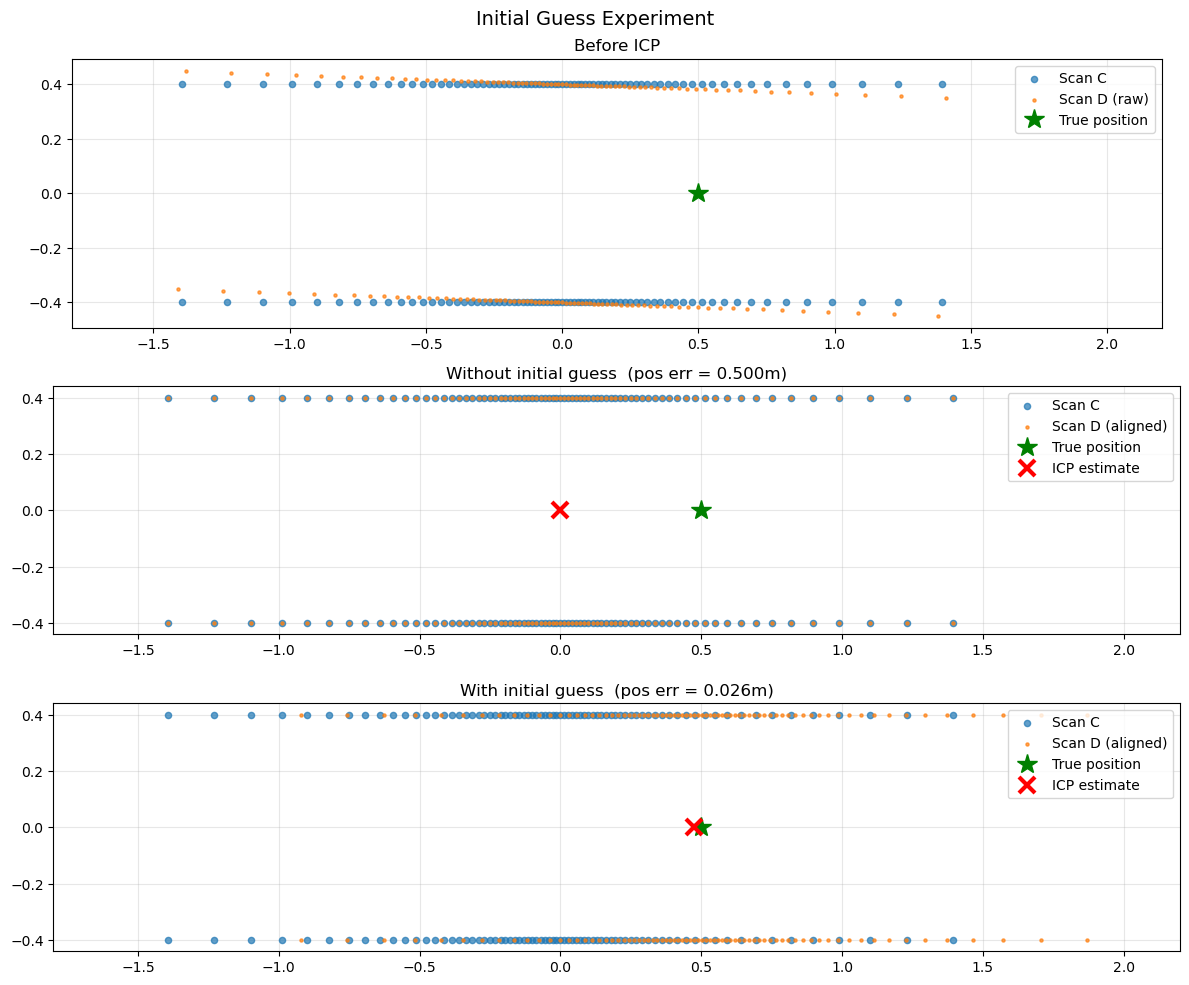

In [2]:
corridor = [
    ((-3.0, -0.4), ( 3.0, -0.4)),
    (( 3.0, -0.4), ( 3.0,  0.4)),
    (( 3.0,  0.4), (-3.0,  0.4)),
    ((-3.0,  0.4), (-3.0, -0.4)),
]

# Robot slides 0.5m along the corridor
pose_C = np.array([0.0, 0.0, 0.0])
pose_D = np.array([0.5, 0.0, np.radians(2)])

_, _, pts_C = simulate_lidar(pose_C, corridor, n_rays=180)
_, _, pts_D = simulate_lidar(pose_D, corridor, n_rays=180)
scan_C = world_to_local(pts_C, pose_C)
scan_D = world_to_local(pts_D, pose_D)

aTb_gt_CD = gtsam.Pose2(*pose_C).between(gtsam.Pose2(*pose_D))

# Without initial guess
aTb_no_guess, err_no_guess = icp(scan_D, scan_C, max_corr_dist=0.3)

# With initial guess
aTb_with_guess, err_with_guess = icp(scan_D, scan_C, max_corr_dist=0.3, initial_guess=aTb_gt_CD)

pos_err_no = np.sqrt((aTb_no_guess.x() - aTb_gt_CD.x())**2 + (aTb_no_guess.y() - aTb_gt_CD.y())**2)
pos_err_with = np.sqrt((aTb_with_guess.x() - aTb_gt_CD.x())**2 + (aTb_with_guess.y() - aTb_gt_CD.y())**2)

print(f"Ground truth: tx={aTb_gt_CD.x():.3f}, ty={aTb_gt_CD.y():.3f}, rot={np.degrees(aTb_gt_CD.theta()):.1f} deg")
print(f"No guess:     tx={aTb_no_guess.x():.3f}, ty={aTb_no_guess.y():.3f}, rot={np.degrees(aTb_no_guess.theta()):.1f} deg  (pos err={pos_err_no:.3f}m)")
print(f"With guess:   tx={aTb_with_guess.x():.3f}, ty={aTb_with_guess.y():.3f}, rot={np.degrees(aTb_with_guess.theta()):.1f} deg  (pos err={pos_err_with:.3f}m)")

# Plot
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
results = [
    (None,           'Before ICP',              None),
    (aTb_no_guess,   'Without initial guess',   pos_err_no),
    (aTb_with_guess, 'With initial guess',       pos_err_with),
]

for ax, (aTb_est, label, pe) in zip(axes, results):
    ax.scatter(scan_C[:, 0], scan_C[:, 1], s=20, alpha=0.7, zorder=2, label='Scan C')
    if aTb_est is None:
        ax.scatter(scan_D[:, 0], scan_D[:, 1], s=5, alpha=0.7, zorder=3, label='Scan D (raw)')
        ax.plot(aTb_gt_CD.x(), aTb_gt_CD.y(), 'g*', ms=15, zorder=5, label='True position')
        ax.set_title(label)
    else:
        scan_D_aligned = apply_pose2(aTb_est, scan_D)
        ax.scatter(scan_D_aligned[:, 0], scan_D_aligned[:, 1], s=5, alpha=0.7, zorder=3, label='Scan D (aligned)')
        ax.plot(aTb_gt_CD.x(), aTb_gt_CD.y(), 'g*', ms=15, zorder=5, label='True position')
        ax.plot(aTb_est.x(), aTb_est.y(), 'rx', ms=12, mew=3, zorder=5, label='ICP estimate')
        ax.set_title(f'{label}  (pos err = {pe:.3f}m)')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3); ax.legend(loc='upper right')
    ax.set_xlim(-1.8, 2.2)

plt.suptitle('Initial Guess Experiment', fontsize=14)
plt.tight_layout()
plt.show()

> **Reflection Q1:** Why does ICP fail in the corridor without an initial guess?

## Robotarium Simulator

The [Robotarium](https://www.robotarium.gatech.edu) is a remotely accessible swarm robotics testbed at Georgia Tech. We use its Python simulator to generate sensor data for our SLAM pipeline.

The simulation cells follow a standard pattern:

1. **Create** the simulator and barrier certificate:
   - `robotarium.Robotarium(...)` initializes robots with given poses
   - `create_unicycle_barrier_certificate_with_boundary()` safety layer (explained below)

2. **Loop** over timesteps:
   - `r.get_poses()` ground truth poses `[x, y, theta]` from overhead tracking
   - `r.get_encoders()` cumulative wheel encoder ticks `[left, right]`
   - `r.set_velocities(ids, dxu)` send unicycle commands `[v, omega]`
   - `r.step()` advance simulation by one timestep (0.033s)

3. **Barrier certificate:** `dxu = bc(dxu, x)` modifies velocities to guarantee no collisions 
   (robot-robot) and no boundary violations (arena walls). It solves a quadratic program (QP) each step. It is required on the real Robotarium.

   **Dev tip:** This is the slowest part of each simulation (~80% of runtime). For single-robot cells, the controller already avoids walls, so you can comment out `dxu = bc(dxu, x)` while iterating on your SLAM code for a speedup. Uncomment before your final run - the autograder uses it, and multi-robot cells need it to prevent inter-robot collisions.

You don't need to understand the Robotarium to complete this assignment - just know that the 
sim cells produce `gt_poses`, `encoder_data`, and `lidar_scans` which your SLAM code consumes. 
See [`robotarium_python_simulator/rps/examples/`](../robotarium_python_simulator/rps/examples/) if you're curious.

## Task 1: encoders_to_odometry (3 pts)

Implement in [p3_lib/slam.py](../p3_lib/slam.py). Convert cumulative wheel encoder ticks into SE2 poses using differential drive kinematics. See the docstring for the conversion steps and parameters.

In [3]:
np.random.seed(42)
N_ROBOTS = 1
SIM_STEPS = 1500

r = robotarium.Robotarium(
    number_of_robots=N_ROBOTS, show_figure=False,
    sim_in_real_time=False, initial_conditions=np.zeros((3, 1)),
)
plt.close('all')
bc = create_unicycle_barrier_certificate_with_boundary()
controller = WaypointController(RECTANGLE_WAYPOINTS, n_robots=N_ROBOTS)

gt_poses = []
enc_data = []

for step in range(SIM_STEPS):
    x = r.get_poses()
    enc = r.get_encoders()            # (2, N) cumulative ticks
    gt_poses.append(x[:, 0].copy())   # (3,)
    enc_data.append(enc[:, 0].copy()) # (2,) [left, right]

    dxu = controller.step(x, None)
    dxu = bc(dxu, x)
    r.set_velocities(np.arange(N_ROBOTS), dxu)
    r.step()

# r.call_at_scripts_end() # print debug stats

gt_poses = np.array(gt_poses) # (T, 3)
enc_data = np.array(enc_data) # (T, 2)

Encoder odometry RMSE: 6.4 cm, final error: 10.3 cm
encoders_to_odometry passed!


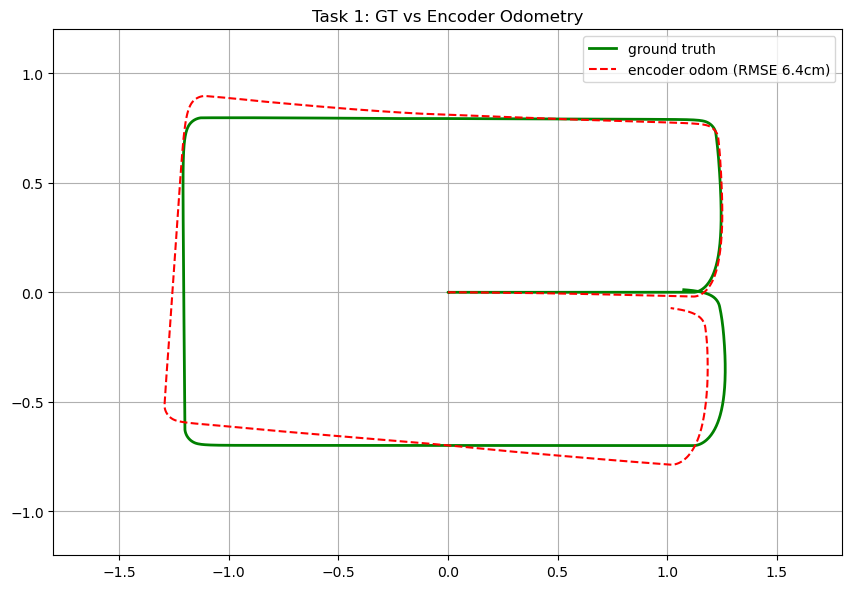

In [4]:
# Run your implementation
poses_enc = encoders_to_odometry(enc_data, gt_poses[0])

# Check
pos_err = np.sqrt(np.mean((poses_enc[:, :2] - gt_poses[:, :2]) ** 2))
final_err = np.linalg.norm(poses_enc[-1, :2] - gt_poses[-1, :2])
print(f"Encoder odometry RMSE: {pos_err*100:.1f} cm, final error: {final_err*100:.1f} cm")
assert pos_err < 0.15, f"RMSE {pos_err:.3f}m exceeds 15cm threshold"
print("encoders_to_odometry passed!")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(*gt_poses[:, :2].T, "g-", lw=2, label="ground truth")
ax.plot(*poses_enc[:, :2].T, "r--", lw=1.5, label=f"encoder odom (RMSE {pos_err*100:.1f}cm)")
ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal"); ax.grid(True); ax.legend()
ax.set_title("Task 1: GT vs Encoder Odometry")
plt.tight_layout(); plt.show()

## Factor Graphs for SLAM

As discussed in lectures, a **factor graph** is a bipartite graph connecting **variable nodes** (unknown robot poses) to **factor nodes** (constraints from measurements).

In pose-graph SLAM, we have three types of factors:

1. **Prior factor** on the first pose - anchors the graph to a known starting position.
2. **Odometry between-factors** between consecutive poses - encodes the relative motion estimated from wheel encoders.
3. **ICP between-factors** between pairs of poses with overlapping scans - encodes the relative transform from scan matching.

For consecutive keyframe pairs, we add **both** an odometry factor and an ICP factor. This gives two independent measurements of the same relative motion, letting the optimizer combine them for a better estimate.

For non-consecutive pairs that happen to be spatially close (loop closures), we add ICP factors only. These are critical: they detect when the robot revisits a location and correct the accumulated drift from odometry.

GTSAM's Levenberg-Marquardt optimizer finds the set of poses that best satisfies all factors simultaneously.

### GTSAM Quick Reference
   - `gtsam.symbol_shorthand.X`: key factory: `X(0)`, `X(1)`, ...
   - `gtsam.Pose2(x, y, theta)`: create SE2 pose
   - `pose_a.between(pose_b)`: relative transform from a to b
   - `gtsam.PriorFactorPose2(key, pose, noise)`: prior factor
   - `gtsam.BetweenFactorPose2(key1, key2, relative_pose, noise)`: between factor
   - `gtsam.noiseModel.Diagonal.Sigmas(np.array([sx, sy, stheta]))`: noise model
   - `graph.add(factor)`: add factor to graph
   - `initial.insert(key, pose)`: set initial value

## Task 2: build_single_robot_graph (6 pts)

Implement in [p3_lib/slam.py](../p3_lib/slam.py). Build a pose-graph for one robot using a prior factor, odometry between-factors, and ICP between-factors (including loop closures). See the docstring for the full specification of factors, noise models, and ICP call pattern.

### Section 1: Single Robot, Predefined Trajectory

The robot follows a rectangular path through the arena. If your SLAM is correct, the optimized trajectory should closely match ground truth and the scan map should show crisp walls.

In [5]:
np.random.seed(0)
N_ROBOTS = 1
SIM_STEPS = 5000
KEYFRAME_EVERY = 20
LIDAR_RAYS = 180

r = robotarium.Robotarium(
    number_of_robots=N_ROBOTS, show_figure=False,
    sim_in_real_time=False, initial_conditions=np.zeros((3, 1)),
)
plt.close('all')
bc = create_unicycle_barrier_certificate_with_boundary()
controller = WaypointController(RECTANGLE_WAYPOINTS, n_robots=N_ROBOTS)

gt_all = []
enc_all = []
keyframe_indices = []
keyframes = []

for step in range(SIM_STEPS):
    x = r.get_poses()
    enc = r.get_encoders()
    pose = x[:, 0].copy()
    gt_all.append(pose)
    enc_all.append(enc[:, 0].copy())

    if step % KEYFRAME_EVERY == 0:
        keyframe_indices.append(step)
        _, _, pts_w = simulate_lidar(pose, ALL_SEGMENTS, n_rays=LIDAR_RAYS)
        keyframes.append({'pose': pose, 'scan_local': world_to_local(pts_w, pose)})

    dxu = controller.step(x, ALL_SEGMENTS)
    dxu = bc(dxu, x)
    r.set_velocities(np.arange(N_ROBOTS), dxu)
    r.step()

# r.call_at_scripts_end() # print debug stats

gt_all = np.array(gt_all)
enc_all = np.array(enc_all)

# Encoder odometry: per-step, then extract at keyframe times
poses_enc = encoders_to_odometry(enc_all, gt_all[0])
poses_odom = poses_enc[keyframe_indices]

poses_gt = np.array([k['pose'] for k in keyframes])
scans_local = [k['scan_local'] for k in keyframes]

In [6]:
# Run your implementation
graph, initial, lc_pairs = build_single_robot_graph(
    poses_odom, scans_local, poses_gt[0],
    search_radius=0.55, icp_threshold=0.02,
    odom_sigmas=np.array([0.005, 0.005, 0.002]),
    lc_stride=1, max_lc_per_node=8,
)
result = gtsam.LevenbergMarquardtOptimizer(graph, initial).optimize()
X = gtsam.symbol_shorthand.X
poses_slam = np.array([
    [result.atPose2(X(i)).x(), result.atPose2(X(i)).y(), result.atPose2(X(i)).theta()]
    for i in range(len(poses_gt))
])

odom_err = np.sqrt(np.mean((poses_odom[:, :2] - poses_gt[:, :2])**2))
slam_err = np.sqrt(np.mean((poses_slam[:, :2] - poses_gt[:, :2])**2))
# With accurate encoder odom, SLAM may not beat odom numerically
assert odom_err * 100 < 5.0
assert slam_err * 100 < 10.0
assert len(lc_pairs) > 0
print(f'Section 1: odom {odom_err*100:.1f} cm, slam {slam_err*100:.1f} cm, lc={len(lc_pairs)}')

Section 1: odom 2.7 cm, slam 0.7 cm, lc=1492


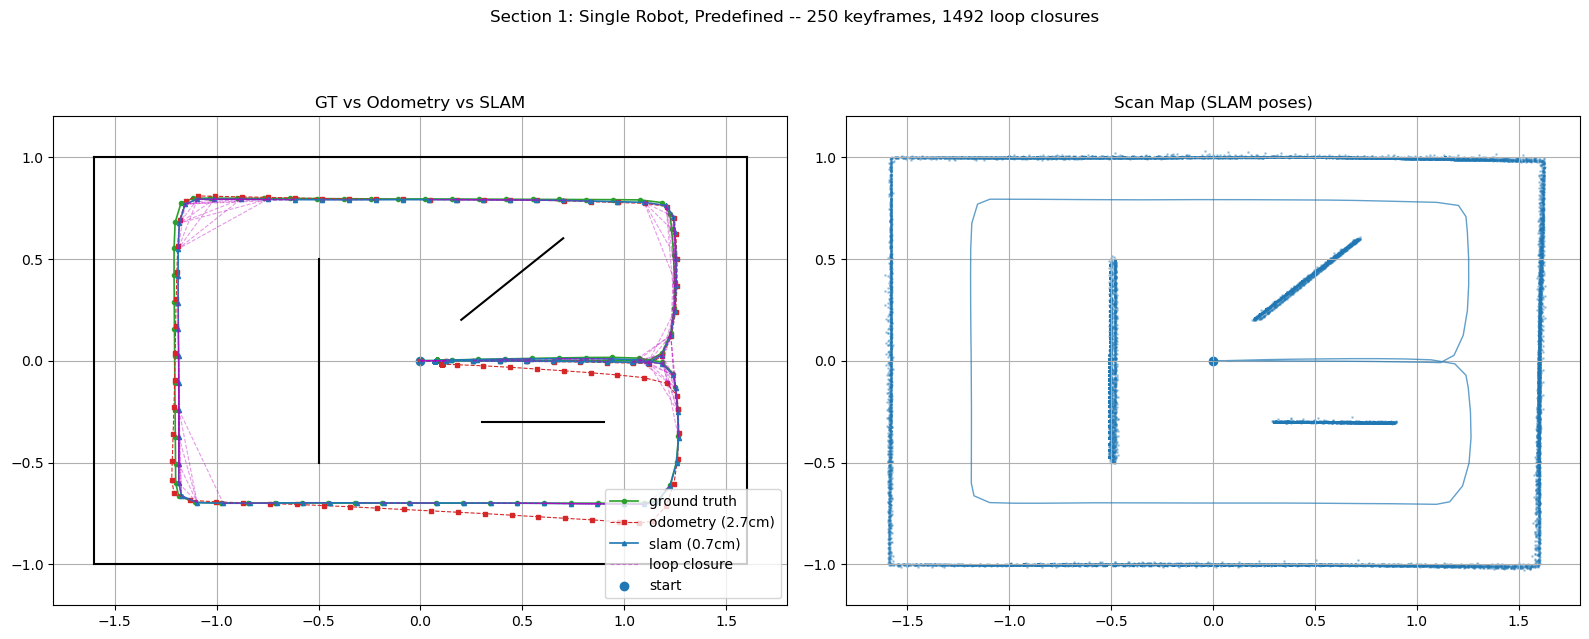

In [7]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
for seg in ALL_SEGMENTS:
    ax.plot([seg[0][0], seg[1][0]], [seg[0][1], seg[1][1]], "k-")
ax.plot(*poses_gt[:, :2].T, "-o", color="tab:green", ms=3, lw=1.2, label="ground truth")
ax.plot(*poses_odom[:, :2].T, "--s", color="tab:red", ms=3, lw=0.8, label=f"odometry ({odom_err*100:.1f}cm)")
ax.plot(*poses_slam[:, :2].T, "-^", color="tab:blue", ms=3, lw=1.2, label=f"slam ({slam_err*100:.1f}cm)")
for k, (j, i_lc) in enumerate(lc_pairs):
    label = "loop closure" if k == 0 else ""
    ax.plot([poses_slam[j, 0], poses_slam[i_lc, 0]],
            [poses_slam[j, 1], poses_slam[i_lc, 1]], "m--", lw=0.8, alpha=0.4, label=label)
ax.scatter(*poses_gt[0, :2], label="start")
ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal"); ax.grid(True); ax.legend(); ax.set_title("GT vs Odometry vs SLAM")

ax = axes[1]
for i in range(len(scans_local)):
    p = poses_slam[i]
    c, s = np.cos(p[2]), np.sin(p[2])
    R = np.array([[c, -s], [s, c]])
    pts_world = scans_local[i] @ R.T + p[:2]
    ax.scatter(pts_world[:, 0], pts_world[:, 1], s=1, c="tab:blue", alpha=0.3)
ax.plot(*poses_slam[:, :2].T, "-", color="tab:blue", lw=1, alpha=0.7)
# ax.plot(*poses_gt[:, :2].T, "-", color="tab:green", lw=1, alpha=0.3, label="GT")
ax.scatter(*poses_slam[0, :2], label="start")
ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal"); ax.grid(True); ax.set_title("Scan Map (SLAM poses)")

plt.suptitle(f"Section 1: Single Robot, Predefined -- {len(scans_local)} keyframes, {len(lc_pairs)} loop closures")
plt.tight_layout(); plt.show()

> **Reflection Q2:** What happens to your map if you set odom_sigmas to [0.5, 0.5, 0.2] and [100, 100, 100]? How do the maps change? Why?

> **Reflection Q3:** How sensitive is your SLAM pipeline to its parameters? Try doubling or halving one of `search_radius`, `icp_threshold`, or `KEYFRAME_EVERY` and see what breaks (or improves).

### Section 2: Single Robot, Random Walk

Same `build_single_robot_graph` code, but the robot explores randomly instead of following a set path. Compare the map quality and RMSE with Section 1. Is the map noisier? Why?

In [8]:
np.random.seed(0)
N_ROBOTS = 1
SIM_STEPS = 5000
KEYFRAME_EVERY = 20
LIDAR_RAYS = 180

r = robotarium.Robotarium(
    number_of_robots=N_ROBOTS, show_figure=False,
    sim_in_real_time=False, initial_conditions=np.zeros((3, 1)),
)
plt.close('all')
bc = create_unicycle_barrier_certificate_with_boundary()
controller = RandomWalkController(
    N_ROBOTS, forward_speed=0.20, detect_dist=0.25,
    turn_steps_range=(10, 40), seed=2,
)

gt_all = []
enc_all = []
keyframe_indices = []
keyframes = []

for step in range(SIM_STEPS):
    x = r.get_poses()
    enc = r.get_encoders()
    pose = x[:, 0].copy()
    gt_all.append(pose)
    enc_all.append(enc[:, 0].copy())

    if step % KEYFRAME_EVERY == 0:
        keyframe_indices.append(step)
        _, _, pts_w = simulate_lidar(pose, ALL_SEGMENTS, n_rays=LIDAR_RAYS)
        keyframes.append({'pose': pose, 'scan_local': world_to_local(pts_w, pose)})

    dxu = controller.step(x, ALL_SEGMENTS)
    dxu = bc(dxu, x)
    r.set_velocities(np.arange(N_ROBOTS), dxu)
    r.step()

# r.call_at_scripts_end() # print debug stats

gt_all = np.array(gt_all)
enc_all = np.array(enc_all)

poses_enc = encoders_to_odometry(enc_all, gt_all[0])
poses_odom = poses_enc[keyframe_indices]

poses_gt = np.array([k['pose'] for k in keyframes])
scans_local = [k['scan_local'] for k in keyframes]

In [9]:
graph, initial, lc_pairs = build_single_robot_graph(
    poses_odom, scans_local, poses_gt[0],
    search_radius=0.55, icp_threshold=0.02,
    odom_sigmas=np.array([0.005, 0.005, 0.002]),
    lc_stride=1, max_lc_per_node=8,
)
result = gtsam.LevenbergMarquardtOptimizer(graph, initial).optimize()
X = gtsam.symbol_shorthand.X
poses_slam = np.array([
    [result.atPose2(X(i)).x(), result.atPose2(X(i)).y(), result.atPose2(X(i)).theta()]
    for i in range(len(poses_gt))
])

odom_err = np.sqrt(np.mean((poses_odom[:, :2] - poses_gt[:, :2])**2))
slam_err = np.sqrt(np.mean((poses_slam[:, :2] - poses_gt[:, :2])**2))
# With accurate encoder odom, SLAM may not beat odom numerically 
assert slam_err * 100 < 10.0
print(f'Section 2: odom {odom_err*100:.1f} cm, slam {slam_err*100:.1f} cm, lc={len(lc_pairs)}')

Section 2: odom 3.9 cm, slam 1.6 cm, lc=1251


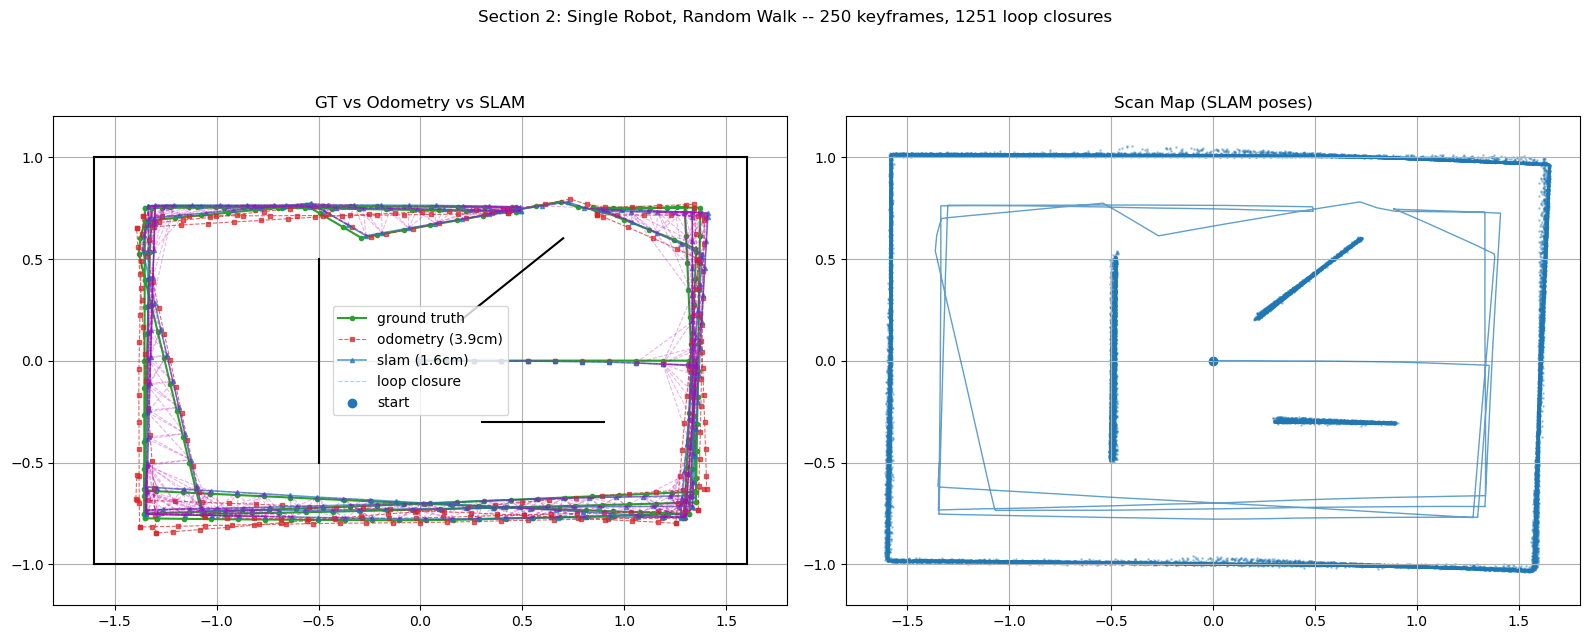

In [10]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
for seg in ALL_SEGMENTS:
    ax.plot([seg[0][0], seg[1][0]], [seg[0][1], seg[1][1]], "k-")
ax.plot(*poses_gt[:, :2].T, "-o", color="tab:green", ms=3, lw=1.5, label="ground truth")
ax.plot(*poses_odom[:, :2].T, "--s", color="tab:red", alpha=0.7, ms=3, lw=0.8, label=f"odometry ({odom_err*100:.1f}cm)")
ax.plot(*poses_slam[:, :2].T, "-^", color="tab:blue", alpha=0.7, ms=3, lw=1.2, label=f"slam ({slam_err*100:.1f}cm)")
for k, (j, i_lc) in enumerate(lc_pairs):
    label = "loop closure" if k == 0 else ""
    ax.plot([poses_slam[j, 0], poses_slam[i_lc, 0]],
            [poses_slam[j, 1], poses_slam[i_lc, 1]], "m--", lw=0.8, alpha=0.3, label=label)
ax.scatter(*poses_gt[0, :2], label="start")
ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal"); ax.grid(True); ax.legend(); ax.set_title("GT vs Odometry vs SLAM")

ax = axes[1]
for i in range(len(scans_local)):
    p = poses_slam[i]
    c, s = np.cos(p[2]), np.sin(p[2])
    R = np.array([[c, -s], [s, c]])
    pts_world = scans_local[i] @ R.T + p[:2]
    ax.scatter(pts_world[:, 0], pts_world[:, 1], s=1, c="tab:blue", alpha=0.3)
ax.plot(*poses_slam[:, :2].T, "-", color="tab:blue", lw=1, alpha=0.7)
# ax.plot(*poses_gt[:, :2].T, "-", color="tab:green", lw=1, alpha=0.3, label="GT")
ax.scatter(*poses_slam[0, :2], label="start")
ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal"); ax.grid(True); ax.set_title("Scan Map (SLAM poses)")

plt.suptitle(f"Section 2: Single Robot, Random Walk -- {len(scans_local)} keyframes, {len(lc_pairs)} loop closures")
plt.tight_layout(); plt.show()

> **Reflection Q4:** Compare this scan map with Section 1. Which is better? Why?

## Simulate Range Measurements

The function `simulate_uwb` in `p3_lib/slam.py` creates noisy inter-robot range measurements (UWB-style) between synchronized keyframes. It is provided for you -- you do not need to implement it. It will be used in the multi-robot SLAM tasks below.

In [11]:
poses_r0 = np.array([[0.0, 0.0, 0.0], [0.1, 0.0, 0.0], [0.2, 0.0, 0.0]])
poses_r1 = np.array([[0.0, 0.55, 0.0], [0.0, 0.6, 0.0], [0.0, 0.65, 0.0]])
edges = simulate_uwb(
    [poses_r0, poses_r1], range_trigger=0.8, range_sigma=0.0,
    max_edges_per_pair=5, seed=1, fallback_to_nearest=False,
)
assert len(edges) == 3 and edges[0][:3] == (0, 1, 0)
print('simulate_uwb sanity check passed!')

simulate_uwb sanity check passed!


## Task 3: build_multi_robot_graph (6 pts)

Implement in [p3_lib/slam.py](../p3_lib/slam.py). Combine multiple single-robot subgraphs plus inter-robot range factors into one pose-graph. Again, see the docstring for the full specification.

### Section 3: Three Robots, Predefined Trajectories

Chain topology: robot 0 (left) and robot 2 (right) never come within range of 
   each other. Robot 1 (center) sweeps the full arena. How do all three robots end up in the same global coordinate frame?

In [12]:
np.random.seed(10)
N_ROBOTS = 3
SIM_STEPS = 7000
KEYFRAME_EVERY = 30
LIDAR_RAYS = 180

init_conds = np.array([
    [-1.0, 0.0, 1.0],  # x
    [ 0.0, 0.0, 0.0],  # y
    [ 0.0, 0.0, 0.0],  # theta
])

r = robotarium.Robotarium(
    number_of_robots=N_ROBOTS, show_figure=False,
    sim_in_real_time=False, initial_conditions=init_conds,
)
plt.close('all')
controller = WaypointController(THREE_ROOM_WAYPOINTS, n_robots=N_ROBOTS)
bc = create_unicycle_barrier_certificate_with_boundary()

gt_all = [[] for _ in range(N_ROBOTS)]
enc_all = [[] for _ in range(N_ROBOTS)]
keyframe_indices = []
keyframes = [[] for _ in range(N_ROBOTS)]

for step in range(SIM_STEPS):
    x = r.get_poses()
    enc = r.get_encoders()

    for ri in range(N_ROBOTS):
        gt_all[ri].append(x[:, ri].copy())
        enc_all[ri].append(enc[:, ri].copy())

    if step % KEYFRAME_EVERY == 0:
        keyframe_indices.append(step)
        for ri in range(N_ROBOTS):
            pose = x[:, ri].copy()
            _, _, pts_w = simulate_lidar(pose, ALL_SEGMENTS_ROOM, n_rays=LIDAR_RAYS)
            keyframes[ri].append({'pose': pose, 'scan_local': world_to_local(pts_w, pose)})

    if controller.done:
        break
    dxu = controller.step(x)
    dxu = bc(dxu, x)
    r.set_velocities(np.arange(N_ROBOTS), dxu)
    r.step()

# r.call_at_scripts_end() # print debug stats

gt_all = [np.array(g) for g in gt_all]
enc_all = [np.array(e) for e in enc_all]

poses_gt_list, scans_local_list, poses_odom_list = [], [], []
for ri in range(N_ROBOTS):
    poses_gt = np.array([k['pose'] for k in keyframes[ri]])
    scans_local = [k['scan_local'] for k in keyframes[ri]]
    # Encoder odometry: per-step, then extract at keyframe times
    poses_enc = encoders_to_odometry(enc_all[ri], gt_all[ri][0])
    poses_odom = poses_enc[keyframe_indices]
    poses_gt_list.append(poses_gt)
    scans_local_list.append(scans_local)
    poses_odom_list.append(poses_odom)

range_edges = simulate_uwb(
    poses_gt_list,
    range_trigger=0.80,
    range_sigma=0.02,
    max_edges_per_pair=20,
    seed=0,
    fallback_to_nearest=False,
)

In [13]:
graph, initial, lc_pairs = build_multi_robot_graph(
    poses_odom_list,
    scans_local_list,
    [poses_gt_list[r_id][0] for r_id in range(N_ROBOTS)],
    range_edges,
    search_radius=0.55,
    icp_threshold=0.02,
    odom_sigmas=np.array([0.005, 0.005, 0.002]),
    range_sigma=0.02,
    max_lc_per_node=8,
    lc_stride=1,
)
result = gtsam.LevenbergMarquardtOptimizer(graph, initial).optimize()
base = 100000
odom_err = []
slam_err = []
poses_slam_list = []
for r_id in range(N_ROBOTS):
    poses_slam = np.array([
        [result.atPose2(gtsam.symbol('x', r_id * base + i)).x(),
         result.atPose2(gtsam.symbol('x', r_id * base + i)).y(),
         result.atPose2(gtsam.symbol('x', r_id * base + i)).theta()]
        for i in range(len(poses_gt_list[r_id]))
    ])
    poses_slam_list.append(poses_slam)
    od = np.sqrt(np.mean((poses_odom_list[r_id][:, :2] - poses_gt_list[r_id][:, :2])**2))
    sm = np.sqrt(np.mean((poses_slam[:, :2] - poses_gt_list[r_id][:, :2])**2))
    odom_err.append(od); slam_err.append(sm)

odom_cm = np.mean(odom_err) * 100.0
slam_cm = np.mean(slam_err) * 100.0
# With accurate encoder odom, SLAM may not beat odom numerically
assert slam_cm < 10.0
print(f'Section 3: avg odom {odom_cm:.1f} cm, slam {slam_cm:.1f} cm; ranges={len(range_edges)}, icp_lc={len(lc_pairs)}')

Section 3: avg odom 3.1 cm, slam 1.0 cm; ranges=40, icp_lc=1453


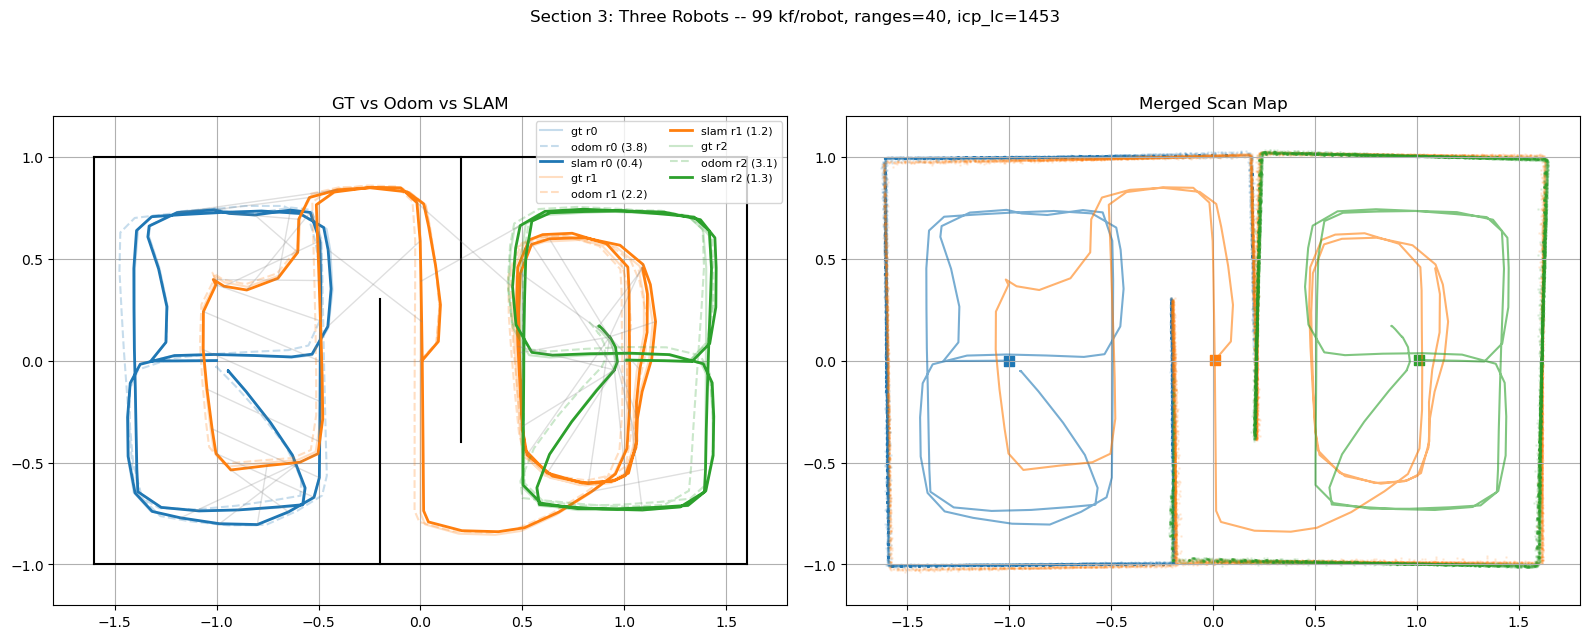

In [14]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors = ["tab:blue", "tab:orange", "tab:green"]

ax = axes[0]
for seg in ALL_SEGMENTS_ROOM:
    ax.plot([seg[0][0], seg[1][0]], [seg[0][1], seg[1][1]], "k-")
for ri in range(N_ROBOTS):
    c = colors[ri]
    ax.plot(*poses_gt_list[ri][:, :2].T, "-", color=c, alpha=0.25, label=f"gt r{ri}")
    ax.plot(*poses_odom_list[ri][:, :2].T, "--", color=c, alpha=0.25, label=f"odom r{ri} ({odom_err[ri]*100:.1f})")
    ax.plot(*poses_slam_list[ri][:, :2].T, "-", color=c, lw=2.0, label=f"slam r{ri} ({slam_err[ri]*100:.1f})")
for (r_id, s_id, i, z) in range_edges:
    pr = poses_slam_list[int(r_id)][int(i), :2]
    ps = poses_slam_list[int(s_id)][int(i), :2]
    ax.plot([pr[0], ps[0]], [pr[1], ps[1]], "0.5", alpha=0.25, lw=1.0)
ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal"); ax.grid(True); ax.legend(ncol=2, fontsize=8)
ax.set_title("GT vs Odom vs SLAM")

ax = axes[1]
for ri in range(N_ROBOTS):
    c = colors[ri]
    for i in range(len(poses_slam_list[ri])):
        p = poses_slam_list[ri][i]
        cc, ss = np.cos(p[2]), np.sin(p[2])
        Rm = np.array([[cc, -ss], [ss, cc]])
        pts_world = scans_local_list[ri][i] @ Rm.T + p[:2]
        ax.scatter(pts_world[:, 0], pts_world[:, 1], s=1, color=c, alpha=0.10)
    ax.plot(*poses_slam_list[ri][:, :2].T, color=c, lw=1.5, alpha=0.6)
    ax.scatter(*poses_slam_list[ri][0, :2], color=c, s=50, marker="s")
ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal"); ax.grid(True); ax.set_title("Merged Scan Map")

plt.suptitle(f"Section 3: Three Robots -- {len(poses_slam_list[0])} kf/robot, ranges={len(range_edges)}, icp_lc={len(lc_pairs)}")
plt.tight_layout(); plt.show()

> **Reflection Q5:** How do robot 0 and robot 2 end up in the same coordinate frame?

> **Reflection Q6:** Is one range measurement enough to determine relative 
    pose? What about two? 

## Section 4: Five Robots, Random Walk (Hidden Map)

Now we test multi-robot SLAM on a more complex environment -- a hidden obstacle map that you'll also use on the real Robotarium. Five robots explore the arena using random walks while collecting encoder odometry, simulated lidar, and inter-robot range measurements.

This section uses the same `build_multi_robot_graph`. The only differences are the obstacle map, number of robots, and navigation strategy.

In [15]:
np.random.seed(7)
N_ROBOTS = 5
SIM_STEPS = 9000 # 3000 # use less steps during development for faster results
KEYFRAME_EVERY = 30
LIDAR_RAYS = 180

r = robotarium.Robotarium(
    number_of_robots=N_ROBOTS, show_figure=False,
    sim_in_real_time=False, initial_conditions=INIT_POSES,
)
plt.close('all')
bc = create_unicycle_barrier_certificate_with_boundary()
controller = RandomWalkController(
    N_ROBOTS, forward_speed=0.20, detect_dist=0.25,
    turn_steps_range=(15, 50),
)

gt_all = [[] for _ in range(N_ROBOTS)]
enc_all = [[] for _ in range(N_ROBOTS)]
keyframe_indices = []
keyframes = [[] for _ in range(N_ROBOTS)]

for step in range(SIM_STEPS):
    x = r.get_poses()
    enc = r.get_encoders()

    for ri in range(N_ROBOTS):
        gt_all[ri].append(x[:, ri].copy())
        enc_all[ri].append(enc[:, ri].copy())

    if step % KEYFRAME_EVERY == 0:
        keyframe_indices.append(step)
        for ri in range(N_ROBOTS):
            pose = x[:, ri].copy()
            _, _, pts_w = simulate_lidar(pose, HIDDEN_SEGMENTS, n_rays=LIDAR_RAYS)
            keyframes[ri].append({'pose': pose, 'scan_local': world_to_local(pts_w, pose)})

    dxu = controller.step(x, HIDDEN_SEGMENTS)
    dxu = bc(dxu, x)
    r.set_velocities(np.arange(N_ROBOTS), dxu)
    r.step()

# r.call_at_scripts_end() # print debug stats

gt_all = [np.array(g) for g in gt_all]
enc_all = [np.array(e) for e in enc_all]

poses_gt_list = []
scans_local_list = []
poses_odom_list = []
for ri in range(N_ROBOTS):
    poses_gt = np.array([k['pose'] for k in keyframes[ri]])
    scans_local = [k['scan_local'] for k in keyframes[ri]]
    poses_enc = encoders_to_odometry(enc_all[ri], gt_all[ri][0])
    poses_odom = poses_enc[keyframe_indices]
    poses_gt_list.append(poses_gt)
    scans_local_list.append(scans_local)
    poses_odom_list.append(poses_odom)

range_edges = simulate_uwb(
    poses_gt_list,
    range_trigger=0.60,
    range_sigma=0.02,
    max_edges_per_pair=20,
    seed=0,
    fallback_to_nearest=True,
)


In [16]:
graph, initial, lc_pairs = build_multi_robot_graph(
    poses_odom_list,
    scans_local_list,
    [poses_gt_list[ri][0] for ri in range(N_ROBOTS)],
    range_edges,
    search_radius=0.65,
    icp_threshold=0.02,
    odom_sigmas=np.array([0.005, 0.005, 0.002]),
    range_sigma=0.02,
    max_lc_per_node=8,
    lc_stride=1,
)
result = gtsam.LevenbergMarquardtOptimizer(graph, initial).optimize()

base = 100000
n_kf = len(poses_gt_list[0])
odom_err = []
slam_err = []
poses_slam_list = []
for ri in range(N_ROBOTS):
    poses_slam = np.array([
        [result.atPose2(gtsam.symbol('x', ri * base + i)).x(),
         result.atPose2(gtsam.symbol('x', ri * base + i)).y(),
         result.atPose2(gtsam.symbol('x', ri * base + i)).theta()]
        for i in range(n_kf)
    ])
    poses_slam_list.append(poses_slam)
    od = np.sqrt(np.mean((poses_odom_list[ri][:, :2] - poses_gt_list[ri][:, :2])**2))
    sm = np.sqrt(np.mean((poses_slam[:, :2] - poses_gt_list[ri][:, :2])**2))
    odom_err.append(od); slam_err.append(sm)
    print(f'  r{ri}: odom {od*100:.1f} cm, slam {sm*100:.1f} cm')

for ri in range(N_ROBOTS):
    assert slam_err[ri] * 100 < 10.0, f"Robot {ri} SLAM RMSE {slam_err[ri]*100:.1f}cm exceeds 10cm"
print(f'Section 4: ranges={len(range_edges)}, icp_lc={len(lc_pairs)}')

  r0: odom 5.8 cm, slam 0.8 cm
  r1: odom 4.3 cm, slam 0.6 cm
  r2: odom 6.6 cm, slam 0.9 cm
  r3: odom 9.5 cm, slam 1.0 cm
  r4: odom 7.0 cm, slam 0.9 cm
Section 4: ranges=200, icp_lc=6938


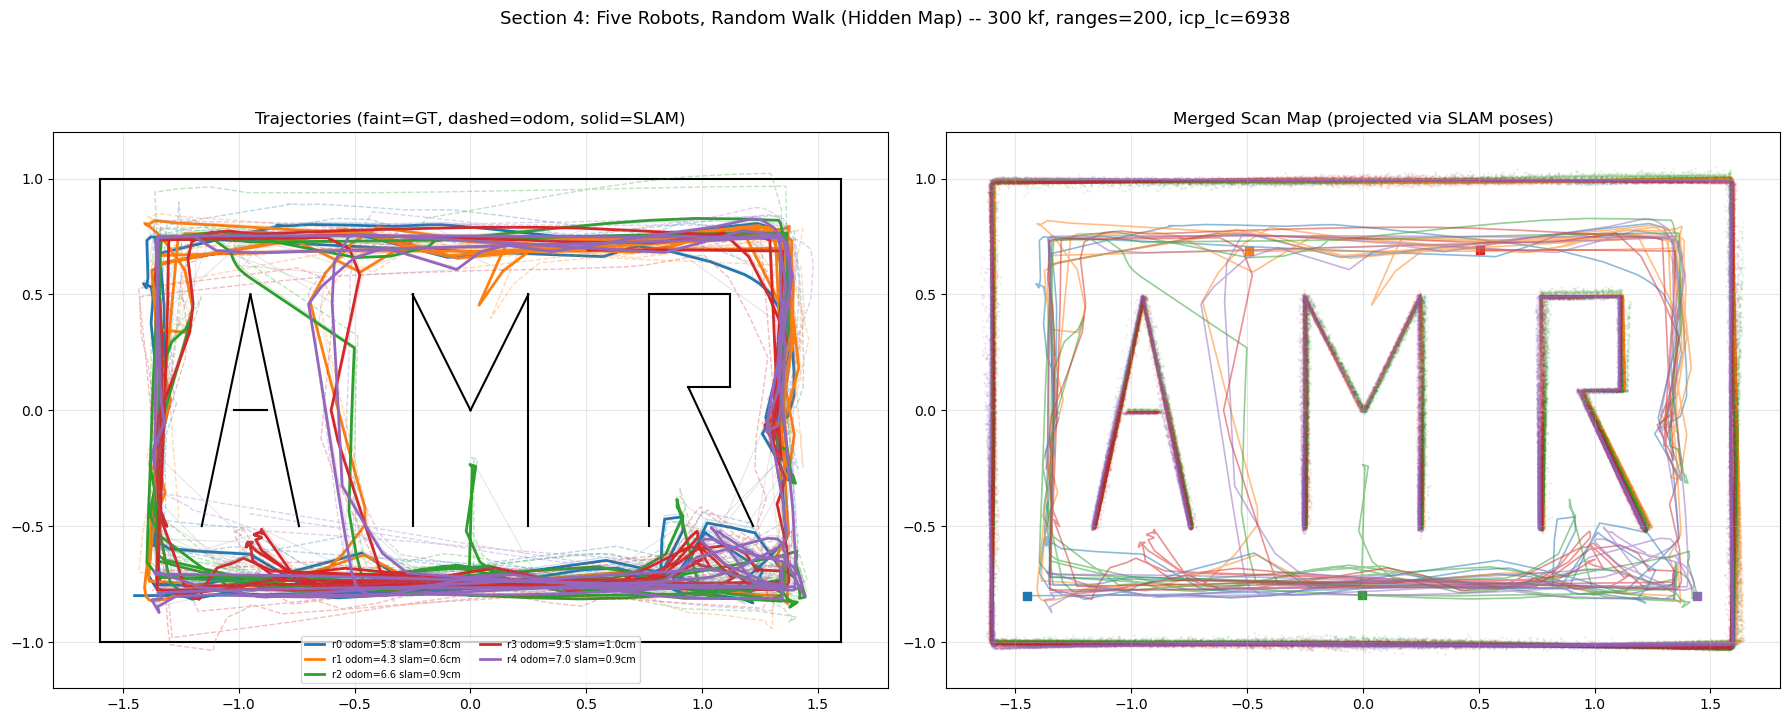

In [17]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

ax = axes[0]
for seg in HIDDEN_SEGMENTS:
    ax.plot([seg[0][0], seg[1][0]], [seg[0][1], seg[1][1]], "k-", lw=1.5)
for ri in range(N_ROBOTS):
    c = colors[ri]
    ax.plot(*poses_gt_list[ri][:, :2].T, "-", color=c, alpha=0.2, lw=1)
    ax.plot(*poses_odom_list[ri][:, :2].T, "--", color=c, alpha=0.3, lw=1)
    ax.plot(*poses_slam_list[ri][:, :2].T, "-", color=c, lw=2.0,
            label=f"r{ri} odom={odom_err[ri]*100:.1f} slam={slam_err[ri]*100:.1f}cm")
for (r_id, s_id, i, z) in range_edges:
    pr = poses_slam_list[int(r_id)][int(i), :2]
    ps = poses_slam_list[int(s_id)][int(i), :2]
    ax.plot([pr[0], ps[0]], [pr[1], ps[1]], "0.5", alpha=0.2, lw=0.8)
ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, ncol=2)
ax.set_title("Trajectories (faint=GT, dashed=odom, solid=SLAM)")

ax = axes[1]
for ri in range(N_ROBOTS):
    c = colors[ri]
    for i in range(n_kf):
        p = poses_slam_list[ri][i]
        cc, ss = np.cos(p[2]), np.sin(p[2])
        Rm = np.array([[cc, -ss], [ss, cc]])
        pts_world = scans_local_list[ri][i] @ Rm.T + p[:2]
        ax.scatter(pts_world[:, 0], pts_world[:, 1], s=0.8, color=c, alpha=0.08)
    ax.plot(*poses_slam_list[ri][:, :2].T, color=c, lw=1.2, alpha=0.5)
    ax.scatter(*poses_slam_list[ri][0, :2], color=c, s=40, marker="s")
ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
ax.set_title("Merged Scan Map (projected via SLAM poses)")

plt.suptitle(f"Section 4: Five Robots, Random Walk (Hidden Map) -- {n_kf} kf, ranges={len(range_edges)}, icp_lc={len(lc_pairs)}", fontsize=13)
plt.tight_layout(); plt.show()

This hidden obstacle map is the same layout used on the real Robotarium. If your map looks recognizable here, you're in good shape for Section 5.

## Section 5: Real Robotarium Data

Now run your SLAM pipeline on real data collected from the Robotarium. 
If you haven't submitted your experiment yet, see the instructions in the [README](../README.md).

> ⚠️ **Robotarium experiments can take up to 2 days to return results.** If you submit the night before the assignment is due, you may not receive your data in time. We cannot grant extensions for Robotarium queue delays. Start early!

You will submit the experiment script **twice** - each run uses different randomized exploration parameters (speed, turn behavior, seed), producing unique trajectories. The parameters are printed in the experiment log.

Place your downloaded `.npy` files in a folder (e.g., `scripts/real_robotarium/run1/`) 
and update the `DATA_DIR` path below. Re-run for each dataset.

The data format:
- `gt_poses.npy`: (T, 3, N_ROBOTS) - ground truth poses from overhead camera
- `encoder_data.npy`: (T, 2, N_ROBOTS) - cumulative encoder ticks [left, right]
- `initial_poses.npy`: (3, N_ROBOTS) - starting poses
- `keyframe_steps.npy`: (n_keyframes,) - which timesteps have lidar data
- `lidar_scans.npy`: (n_keyframes, N_ROBOTS, 180, 2) - lidar scans in local frame
- `range_edges.npy`: (n_edges, 4) - [robot_r, robot_s, keyframe_idx, range_measurement]

In [27]:
DATA_DIR = '../scripts/real_robotarium/run1'  # <-- UPDATE THIS PATH

# Load real data
gt_poses_all = np.load(f'{DATA_DIR}/gt_poses.npy')         # (T, 3, N_ROBOTS)
encoder_data_all = np.load(f'{DATA_DIR}/encoder_data.npy') # (T, 2, N_ROBOTS)
initial_poses = np.load(f'{DATA_DIR}/initial_poses.npy')   # (3, N_ROBOTS)
keyframe_steps = np.load(f'{DATA_DIR}/keyframe_steps.npy') # (n_keyframes,)
lidar_scans = np.load(f'{DATA_DIR}/lidar_scans.npy')       # (n_kf, N_ROBOTS, 180, 2)
range_edges_raw = np.load(f'{DATA_DIR}/range_edges.npy')   # (n_edges, 4)

N_ROBOTS = gt_poses_all.shape[2]
n_keyframes = len(keyframe_steps)
print(f'Loaded: {N_ROBOTS} robots, {n_keyframes} keyframes, '
      f'{len(range_edges_raw)} range edges, {len(gt_poses_all)} timesteps')

# Convert range_edges to list-of-tuples format
range_edges = [(int(r), int(s), int(kf_idx), float(z))
               for r, s, kf_idx, z in range_edges_raw]

# Per-robot: encoder odometry -> extract at keyframe times -> scans
poses_gt_list = []
scans_local_list = []
poses_odom_list = []

for ri in range(N_ROBOTS):
    # Encoder odometry for all timesteps
    poses_enc = encoders_to_odometry(encoder_data_all[:, :, ri], initial_poses[:, ri])
    # Extract at keyframe times
    poses_odom = poses_enc[keyframe_steps]
    poses_odom_list.append(poses_odom)

    # Ground truth at keyframe times
    poses_gt = gt_poses_all[keyframe_steps, :, ri]  # (n_kf, 3)
    poses_gt_list.append(poses_gt)

    # Lidar scans already in local frame
    scans_local_list.append([lidar_scans[k, ri] for k in range(n_keyframes)])

# Build multi-robot graph and optimize
graph, initial, lc_pairs = build_multi_robot_graph(
    poses_odom_list,
    scans_local_list,
    [poses_gt_list[ri][0] for ri in range(N_ROBOTS)],
    range_edges,
    search_radius=0.65,
    icp_threshold=0.02,
    odom_sigmas=np.array([0.005, 0.005, 0.002]),
    range_sigma=0.02,
    max_lc_per_node=8,
    lc_stride=1,
)
result = gtsam.LevenbergMarquardtOptimizer(graph, initial).optimize()

# Extract SLAM poses and compute errors
base = 100000
odom_err = []
slam_err = []
poses_slam_list = []
for ri in range(N_ROBOTS):
    poses_slam = np.array([
        [result.atPose2(gtsam.symbol('x', ri * base + i)).x(),
         result.atPose2(gtsam.symbol('x', ri * base + i)).y(),
         result.atPose2(gtsam.symbol('x', ri * base + i)).theta()]
        for i in range(n_keyframes)
    ])
    poses_slam_list.append(poses_slam)
    od = np.sqrt(np.mean((poses_odom_list[ri][:, :2] - poses_gt_list[ri][:, :2])**2))
    sm = np.sqrt(np.mean((poses_slam[:, :2] - poses_gt_list[ri][:, :2])**2))
    odom_err.append(od); slam_err.append(sm)
    print(f'  r{ri}: odom {od*100:.1f} cm, slam {sm*100:.1f} cm')

print(f'Section 5: ranges={len(range_edges)}, icp_lc={len(lc_pairs)}')

Loaded: 5 robots, 200 keyframes, 643 range edges, 6000 timesteps
  r0: odom 27.3 cm, slam 1.8 cm
  r1: odom 7.5 cm, slam 2.3 cm
  r2: odom 14.4 cm, slam 1.8 cm
  r3: odom 21.0 cm, slam 3.5 cm
  r4: odom 8.1 cm, slam 1.4 cm
Section 5: ranges=643, icp_lc=4641


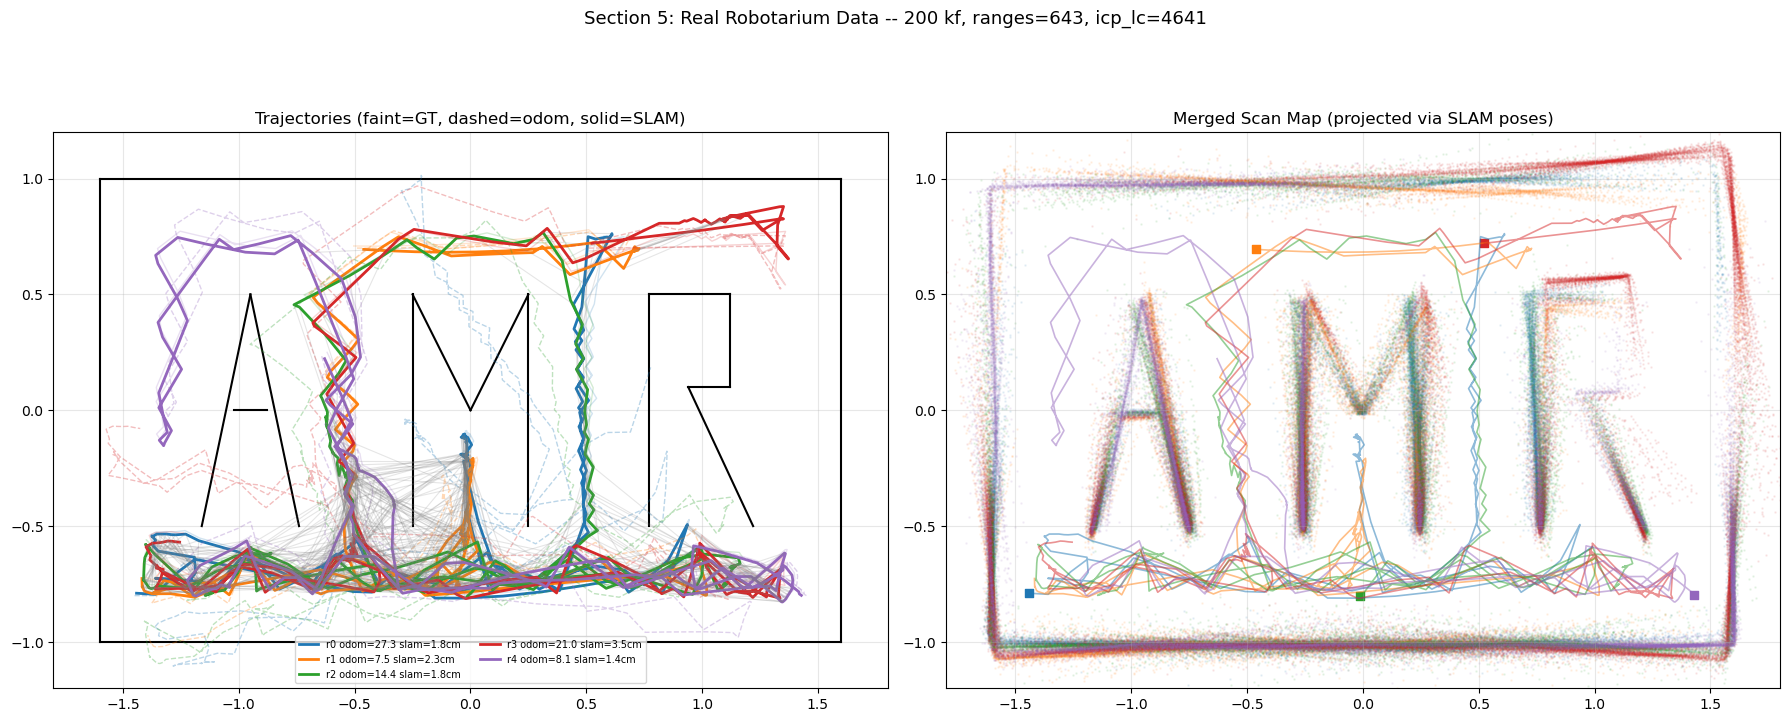

In [29]:
# Plot
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

ax = axes[0]
for seg in HIDDEN_SEGMENTS:
    ax.plot([seg[0][0], seg[1][0]], [seg[0][1], seg[1][1]], 'k-', lw=1.5)
for ri in range(N_ROBOTS):
    c = colors[ri % len(colors)]
    ax.plot(*poses_gt_list[ri][:, :2].T, '-', color=c, alpha=0.2, lw=1)
    ax.plot(*poses_odom_list[ri][:, :2].T, '--', color=c, alpha=0.3, lw=1)
    ax.plot(*poses_slam_list[ri][:, :2].T, '-', color=c, lw=2.0,
            label=f'r{ri} odom={odom_err[ri]*100:.1f} slam={slam_err[ri]*100:.1f}cm')
for (r_id, s_id, i, z) in range_edges:
    pr = poses_slam_list[int(r_id)][int(i), :2]
    ps = poses_slam_list[int(s_id)][int(i), :2]
    ax.plot([pr[0], ps[0]], [pr[1], ps[1]], '0.5', alpha=0.2, lw=0.8)
ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, ncol=2)
ax.set_title('Trajectories (faint=GT, dashed=odom, solid=SLAM)')

ax = axes[1]
# for seg in HIDDEN_SEGMENTS:
#     ax.plot([seg[0][0], seg[1][0]], [seg[0][1], seg[1][1]], 'k-', lw=1.5)
for ri in range(N_ROBOTS):
    c = colors[ri % len(colors)]
    for i in range(n_keyframes):
        p = poses_slam_list[ri][i]
        cc, ss = np.cos(p[2]), np.sin(p[2])
        Rm = np.array([[cc, -ss], [ss, cc]])
        scan = scans_local_list[ri][i]
        valid = ~np.isnan(scan).any(axis=1)
        pts_world = scan[valid] @ Rm.T + p[:2]
        ax.scatter(pts_world[:, 0], pts_world[:, 1], s=0.8, color=c, alpha=0.08)
    ax.plot(*poses_slam_list[ri][:, :2].T, color=c, lw=1.2, alpha=0.5)
    ax.scatter(*poses_slam_list[ri][0, :2], color=c, s=40, marker='s')
ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_title('Merged Scan Map (projected via SLAM poses)')

plt.suptitle(f'Section 5: Real Robotarium Data -- {n_keyframes} kf, '
             f'ranges={len(range_edges)}, icp_lc={len(lc_pairs)}', fontsize=13)
plt.tight_layout(); plt.show()

> **Reflection Q7:** Analyze your two Robotarium runs. Which produced a better map, and why?  What exploration parameters mattered most?

> **Reflection Q8:** Compare your best Robotarium map with your Section 4 simulation map. What's different, and why?

> **Reflection Q9:** What surprised you most in this project?